In [12]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

In [13]:
# ==========================================================
# Dense Coding using 5 qubit Cluster State
# ==========================================================
qc = QuantumCircuit(5,5)

# ----------------------------------------------------------
# Cluster State Preparation
# ----------------------------------------------------------

qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)
qc.h(4)
qc.barrier()
qc.cz(0,1)
qc.cz(1,2)
qc.cz(2,3)
qc.cz(3,4) 
qc.barrier()
qc.h(0)
qc.h(2)
qc.h(4)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

In [14]:
# ----------------------------------------------------------
# Alice Encoding
# ----------------------------------------------------------
message = "11000"  
if message == "00000":
    pass

elif message == "10100":
    qc.x(1)

elif message == "11100":
    qc.y(1)

elif message == "01000":
    qc.z(1)

elif message == "10000":
    qc.x(0)

elif message == "00100":
    qc.x(0)
    qc.x(1)

elif message == "01100":
    qc.x(0)
    qc.y(1)

elif message == "11000":
    qc.x(0)
    qc.z(1)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

In [15]:
# ----------------------------------------------------------
# Bob Decoding
# ----------------------------------------------------------

qc.h(0)
qc.h(2)
qc.h(4)
qc.barrier()

qc.cz(3,4)
qc.cz(2,3)
qc.cz(1,2)
qc.cz(0,1)
qc.barrier()

qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)
qc.h(4)
qc.barrier()

qc.measure([0,1,2,3,4],[0,1,2,3,4])

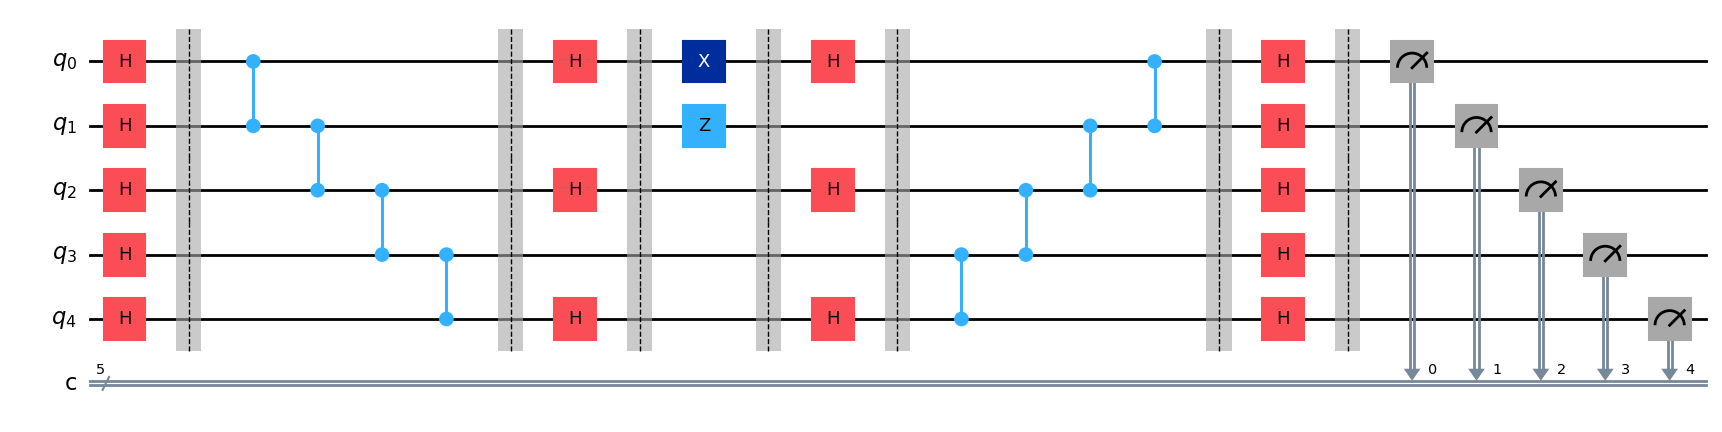

In [16]:
qc.draw(output="mpl")

In [17]:
print(qc.depth())

14


{'00000': 0, '00001': 0, '00010': 0, '00011': 4096, '00100': 0, '00101': 0, '00110': 0, '00111': 0, '01000': 0, '01001': 0, '01010': 0, '01011': 0, '01100': 0, '01101': 0, '01110': 0, '01111': 0, '10000': 0, '10001': 0, '10010': 0, '10011': 0, '10100': 0, '10101': 0, '10110': 0, '10111': 0, '11000': 0, '11001': 0, '11010': 0, '11011': 0, '11100': 0, '11101': 0, '11110': 0, '11111': 0}


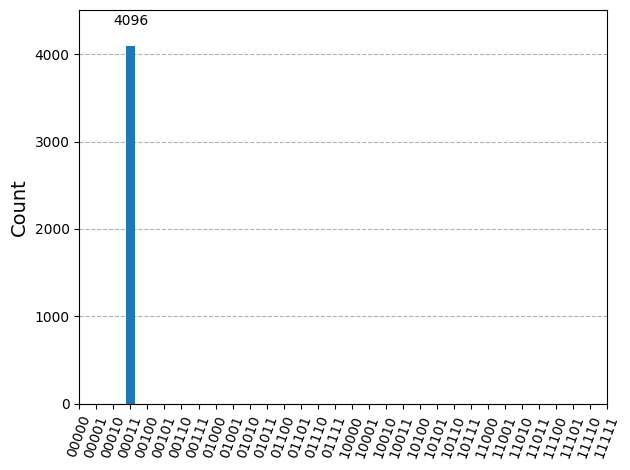

In [18]:
simulator = Aer.get_backend('qasm_simulator')

result = simulator.run(qc, shots=4096).result()
counts = result.get_counts()

# Add missing states with zero counts
all_states = ['00000', '00001', '00010', '00011', '00100', '00101', '00110', '00111', '01000', '01001', '01010', '01011', '01100', '01101', '01110', '01111', '10000', '10001', '10010', '10011', '10100', '10101', '10110', '10111', '11000', '11001', '11010', '11011', '11100', '11101', '11110', '11111']

counts_complete = {state: counts.get(state, 0) for state in all_states}

print(counts_complete)

plot_histogram(counts_complete)

In [ ]:
import numpy as np
from itertools import product

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# ==========================================================
# Prepare 5-Qubit Cluster State
# ==========================================================

def cluster5():

    qc = QuantumCircuit(5)

    # Preparation

    qc.h([0,1,2,3,4])

    qc.cz(0,1)
    qc.cz(1,2)
    qc.cz(2,3)
    qc.cz(3,4)

    qc.h(0)
    qc.h(2)
    qc.h(4)

    return qc


base = cluster5()


paulis = ['I','X','Y','Z']

labels = []
encoded_states = []

for p0, p1 in product(paulis, repeat=2):

    qc = base.copy()

    if p0 != 'I':
        getattr(qc, p0.lower())(0)

    if p1 != 'I':
        getattr(qc, p1.lower())(1)

    psi = Statevector.from_instruction(qc)

    encoded_states.append(psi.data)
    labels.append(p0+p1)

# Gram Matrix

N = len(encoded_states)

G = np.zeros((N,N), dtype=complex)

for i in range(N):
    for j in range(N):
        G[i,j] = np.vdot(encoded_states[i],
                         encoded_states[j])

print("="*60)
print("GRAM MATRIX")
print("="*60)

print(np.round(np.abs(G),6))

# Check Orthogonality

if np.allclose(G, np.eye(N), atol=1e-10):

    print("\nAll encoded states are mutually orthogonal.")

else:

    print("\nEncoded states are NOT mutually orthogonal.")


GRAM MATRIX
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]

Encoded states are NOT mutually orthogonal.


In [20]:
print("\n======================================================")
print("Non-Orthogonal Pairs")
print("======================================================\n")

count = 0

for i in range(N):
    for j in range(i + 1, N):

        overlap = np.vdot(encoded_states[i], encoded_states[j])

        if abs(overlap) > 1e-10:

            print(f"{labels[i]:>2}   <->   {labels[j]:>2}")

            print("Overlap = ", overlap)

            print()

            count += 1

print("Total Non-Orthogonal Pairs =", count)


Non-Orthogonal Pairs

II   <->   ZZ
Overlap =  (0.9999999999999987+0j)

IX   <->   ZY
Overlap =  0.9999999999999987j

IY   <->   ZX
Overlap =  -0.9999999999999987j

IZ   <->   ZI
Overlap =  (0.9999999999999987+0j)

XI   <->   YZ
Overlap =  0.9999999999999987j

XX   <->   YY
Overlap =  (-0.9999999999999987+0j)

XY   <->   YX
Overlap =  (0.9999999999999987+0j)

XZ   <->   YI
Overlap =  0.9999999999999987j

Total Non-Orthogonal Pairs = 8


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

tol = 1e-10

graph = nx.Graph()

# 64 vertices
graph.add_nodes_from(range(16))

for i in range(16):
    for j in range(i+1,16):

        if abs(G[i,j]) < tol:
            graph.add_edge(i,j)

print("Vertices :",graph.number_of_nodes())
print("Edges    :",graph.number_of_edges())

Vertices : 16
Edges    : 112


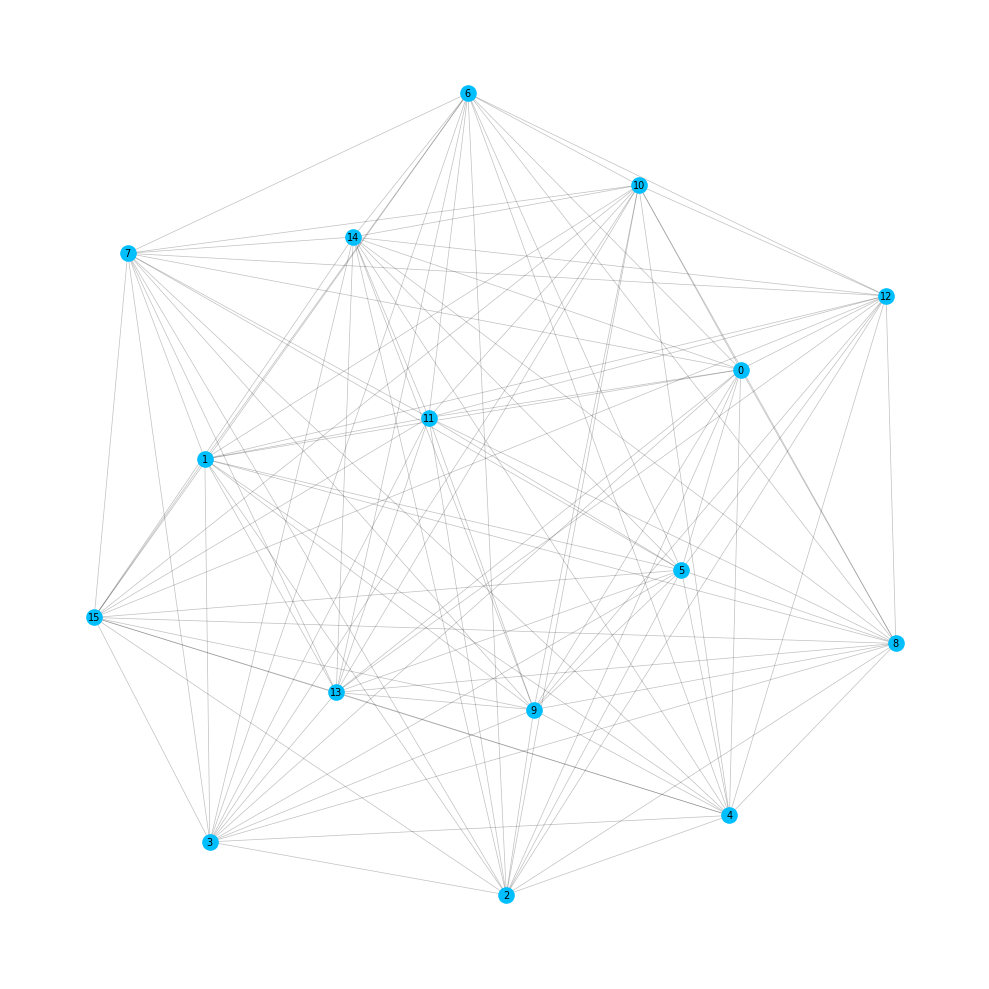

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))

pos = nx.spring_layout(
    graph,
    seed=1,
    k=0.35
)

nx.draw_networkx_nodes(
    graph,
    pos,
    node_size=120,
    node_color='deepskyblue'
)

nx.draw_networkx_edges(
    graph,
    pos,
    alpha=0.25,
    width=0.5
)

nx.draw_networkx_labels(
    graph,
    pos,
    font_size=7
)


plt.axis("off")

plt.tight_layout()

plt.show()